In [1003]:
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math
from collections import defaultdict
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter
import colorsys
import matplotlib.colors

In [1004]:
DATA_DIR = "./data"
CSV_DIR  = f"{DATA_DIR}/csv"

In [1005]:
# ── Load both embeddings ───────────────────────────────────────────────────────
with open(f"{DATA_DIR}/embeddings/genre_embeddings.json") as f:
    genre_raw = json.load(f)

with open(f"{DATA_DIR}/embeddings/tag_embeddings.json") as f:
    tag_raw = json.load(f)

genres    = list(genre_raw.keys())
tags      = list(tag_raw.keys())
genre2idx = {g: i for i, g in enumerate(genres)}
tag2idx   = {t: i for i, t in enumerate(tags)}

G      = np.array(list(genre_raw.values()), dtype=np.float32)
T      = np.array(list(tag_raw.values()),   dtype=np.float32)
G_norm = G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-9)
T_norm = T / (np.linalg.norm(T, axis=1, keepdims=True) + 1e-9)

print(f"genres: {len(genres)} | dim={G.shape[1]}")
print(f"tags:   {len(tags)}   | dim={T.shape[1]}")

genres: 1305 | dim=32
tags:   985   | dim=64


In [1006]:
# ── PCA — fit on embeddings to find most discriminative directions ─────────────
pca_genre = PCA(n_components=3).fit(G_norm)
pca_tag   = PCA(n_components=3).fit(T_norm)

def embedding_to_rgb_pca(vec, pca, temp=3.0, hue_offset=0.15):
    projected = pca.transform(vec.reshape(1, -1))[0]
    p         = np.tanh(projected * temp)
    h         = (np.arctan2(p[1], p[0]) / (2 * np.pi) + 0.5 + hue_offset) % 1.0
    s         = np.clip(np.sqrt(p[0]**2 + p[1]**2) * 0.4 + 0.6, 0.65, 1.0)
    v         = np.clip((p[2] + 1) / 2 * 0.35 + 0.65, 0.65, 1.0)
    r, g, b   = colorsys.hsv_to_rgb(h, s, v)
    return np.array([r * 255, g * 255, b * 255], dtype=np.uint8)

In [1007]:
# ── Color mapping ──────────────────────────────────────────────────────────────
# small override for genres where PCA mapping is obviously wrong
COLOR_OVERRIDES = {
    "metal":     np.array([150, 0,   0],   dtype=np.uint8),
    "punk":      np.array([180, 20,  20],  dtype=np.uint8),
    "grunge":    np.array([100, 60,  20],  dtype=np.uint8),
    "rap":       np.array([40,  40,  40],  dtype=np.uint8),
    "hip hop":   np.array([60,  60,  80],  dtype=np.uint8),
    "folk":      np.array([120, 180, 60],  dtype=np.uint8),
    "country":   np.array([210, 140, 50],  dtype=np.uint8),
    "classical": np.array([200, 200, 240], dtype=np.uint8),
    "ambient":   np.array([80,  120, 200], dtype=np.uint8),
    "blues":     np.array([30,  80,  180], dtype=np.uint8),
}

In [1008]:
def get_rgb_genre(token):
    t = token.lower()
    if t in COLOR_OVERRIDES:
        return COLOR_OVERRIDES[t]
    if t not in genre2idx:
        return None
    return embedding_to_rgb_pca(G_norm[genre2idx[t]], pca_genre)

In [1009]:
def get_rgb_tag(token):
    t = token.lower()
    if t not in tag2idx:
        return None
    return embedding_to_rgb_pca(T_norm[tag2idx[t]], pca_tag)

In [1010]:
def generate_multi_blob(song, size=600):
    # average all genre vectors → one combined genre color
    combined_g = np.zeros(G.shape[1], dtype=np.float32)
    total_g    = 0.0
    for genre in song.get("genres", []):
        t = genre.lower()
        if t in genre2idx:
            combined_g += G_norm[genre2idx[t]]
            total_g    += 1.0

    if total_g == 0:
        return None

    combined_g /= total_g
    combined_g  = combined_g / (np.linalg.norm(combined_g) + 1e-9)

    override_colors = []
    for genre in song.get("genres", []):
        if genre.lower() in COLOR_OVERRIDES:
            override_colors.append(COLOR_OVERRIDES[genre.lower()].astype(np.float32))

    if override_colors:
        genre_rgb = np.mean(override_colors, axis=0)
    else:
        genre_rgb = embedding_to_rgb_pca(combined_g, pca_genre).astype(np.float32)

    # average all tag vectors → one combined tag color
    combined_t = np.zeros(T.shape[1], dtype=np.float32)
    total_t    = 0.0
    for tag in song.get("tags", []):
        t = tag.lower()
        if t in tag2idx:
            combined_t += T_norm[tag2idx[t]]
            total_t    += 1.0

    if total_t > 0:
        combined_t /= total_t
        combined_t  = combined_t / (np.linalg.norm(combined_t) + 1e-9)
        tag_rgb     = embedding_to_rgb_pca(combined_t, pca_tag).astype(np.float32)
    else:
        tag_rgb = genre_rgb.copy()

    # ── build gradient canvas ─────────────────────────────────────────────────
    canvas = np.zeros((size, size, 3), dtype=np.float32)
    cx, cy = size // 2, size // 2

    y_grid, x_grid = np.mgrid[0:size, 0:size]

    # large noise field for organic shape
    np.random.seed(None)
    noise_x = gaussian_filter(np.random.randn(size, size).astype(np.float32), sigma=8) * size * 0.04
    noise_y = gaussian_filter(np.random.randn(size, size).astype(np.float32), sigma=8) * size * 0.04
    x_warped = x_grid + noise_x
    y_warped = y_grid + noise_y

    # normalized distance from center (warped) → 0 at center, 1 at edge
    dist     = np.sqrt((x_warped - cx)**2 + (y_warped - cy)**2)
    max_dist = size * 0.48
    t_map = np.clip(dist / (size * 0.45), 0, 1)  # 0=center, 1=edge

    # ── directional lighting (top-right) ───────────────────────
    lx, ly = 1.0, -1.0  # top-right light direction

    # normalize coordinates around center
    nx = (x_grid - cx) / size
    ny = (y_grid - cy) / size

    light = nx * lx + ny * ly

    # normalize to 0–1
    light = (light - light.min()) / (light.max() - light.min() + 1e-9)

    # smooth blob mask — 1 inside, fades at edge
    blob_mask = np.clip(1 - (dist / (size * 0.45)), 0, 1)

    # gradient: genre color at center → tag color at edge
    for c in range(3):
        gradient         = genre_rgb[c] * (1 - t_map) + tag_rgb[c] * t_map
        shading = (0.6 + 0.4 * light)  # controls strength
        canvas[:, :, c] = gradient * blob_mask * shading

    # very light final blur just to smooth pixel edges
    for c in range(3):
        canvas[:, :, c] = gaussian_filter(canvas[:, :, c], sigma=1)

    global_max = canvas.max()
    if global_max > 0:
        canvas = canvas / global_max

    canvas = np.power(canvas, 0.5)
    return Image.fromarray(np.clip(canvas * 255, 0, 255).astype(np.uint8), mode='RGB')

In [1011]:
def generate_multi_blob(song, size=600, max_blobs=8):
    canvas = np.zeros((size, size, 3), dtype=np.float32)

    cx, cy = size // 2, size // 2
    y_grid, x_grid = np.mgrid[0:size, 0:size]

    radius_base = size * 0.18  # smaller individual blobs

    blobs = []

    # ── GENRE BLOBS (strong anchors) ─────────────────────────
    for genre in song.get("genres", []):
        t = genre.lower()
        if t not in genre2idx:
            continue

        vec = G_norm[genre2idx[t]]
        color = embedding_to_rgb_pca(vec, pca_genre).astype(np.float32)

        # random offset around center (but stable-ish)
        angle = np.random.uniform(0, 2*np.pi)
        r = np.random.uniform(0, size * 0.12)

        bx = cx + np.cos(angle) * r
        by = cy + np.sin(angle) * r

        blobs.append((bx, by, radius_base * 1.3, color))

    # ── TAG BLOBS (smaller satellites) ───────────────────────
    for tag in song.get("tags", []):
        if len(blobs) >= max_blobs:
            break

        t = tag.lower()
        if t not in tag2idx:
            continue

        vec = T_norm[tag2idx[t]]
        color = embedding_to_rgb_pca(vec, pca_tag).astype(np.float32)

        angle = np.random.uniform(0, 2*np.pi)
        r = np.random.uniform(0, size * 0.2)

        bx = cx + np.cos(angle) * r
        by = cy + np.sin(angle) * r

        blobs.append((bx, by, radius_base * 0.7, color))

    # ── RENDER BLOBS ─────────────────────────────────────────
    for bx, by, radius, color in blobs:

        dist = np.sqrt((x_grid - bx)**2 + (y_grid - by)**2)
        t = np.clip(dist / radius, 0, 1)

        mask = (1 - t) ** 2  # smooth falloff

        for c in range(3):
            canvas[:, :, c] += color[c] * mask * 0.05

    # ── FINAL CLEANUP ────────────────────────────────────────
    canvas = np.clip(canvas, 0, 1)
    canvas = np.power(canvas, 0.75)
    canvas = np.clip(canvas, 0, 1)

    return Image.fromarray(
        (canvas * 255).astype(np.uint8),
        mode="RGB"
    )

C:\Users\chand\AppData\Local\Temp\ipykernel_24832\558955459.py:47: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_24832\558955459.py:47: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_24832\558955459.py:47: UserWarning: Glyph 40643 (\N{CJK UNIFIED IDEOGRAPH-9EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_24832\558955459.py:47: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_24832\558955459.py:47: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_24832\558955459.py:47: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing 

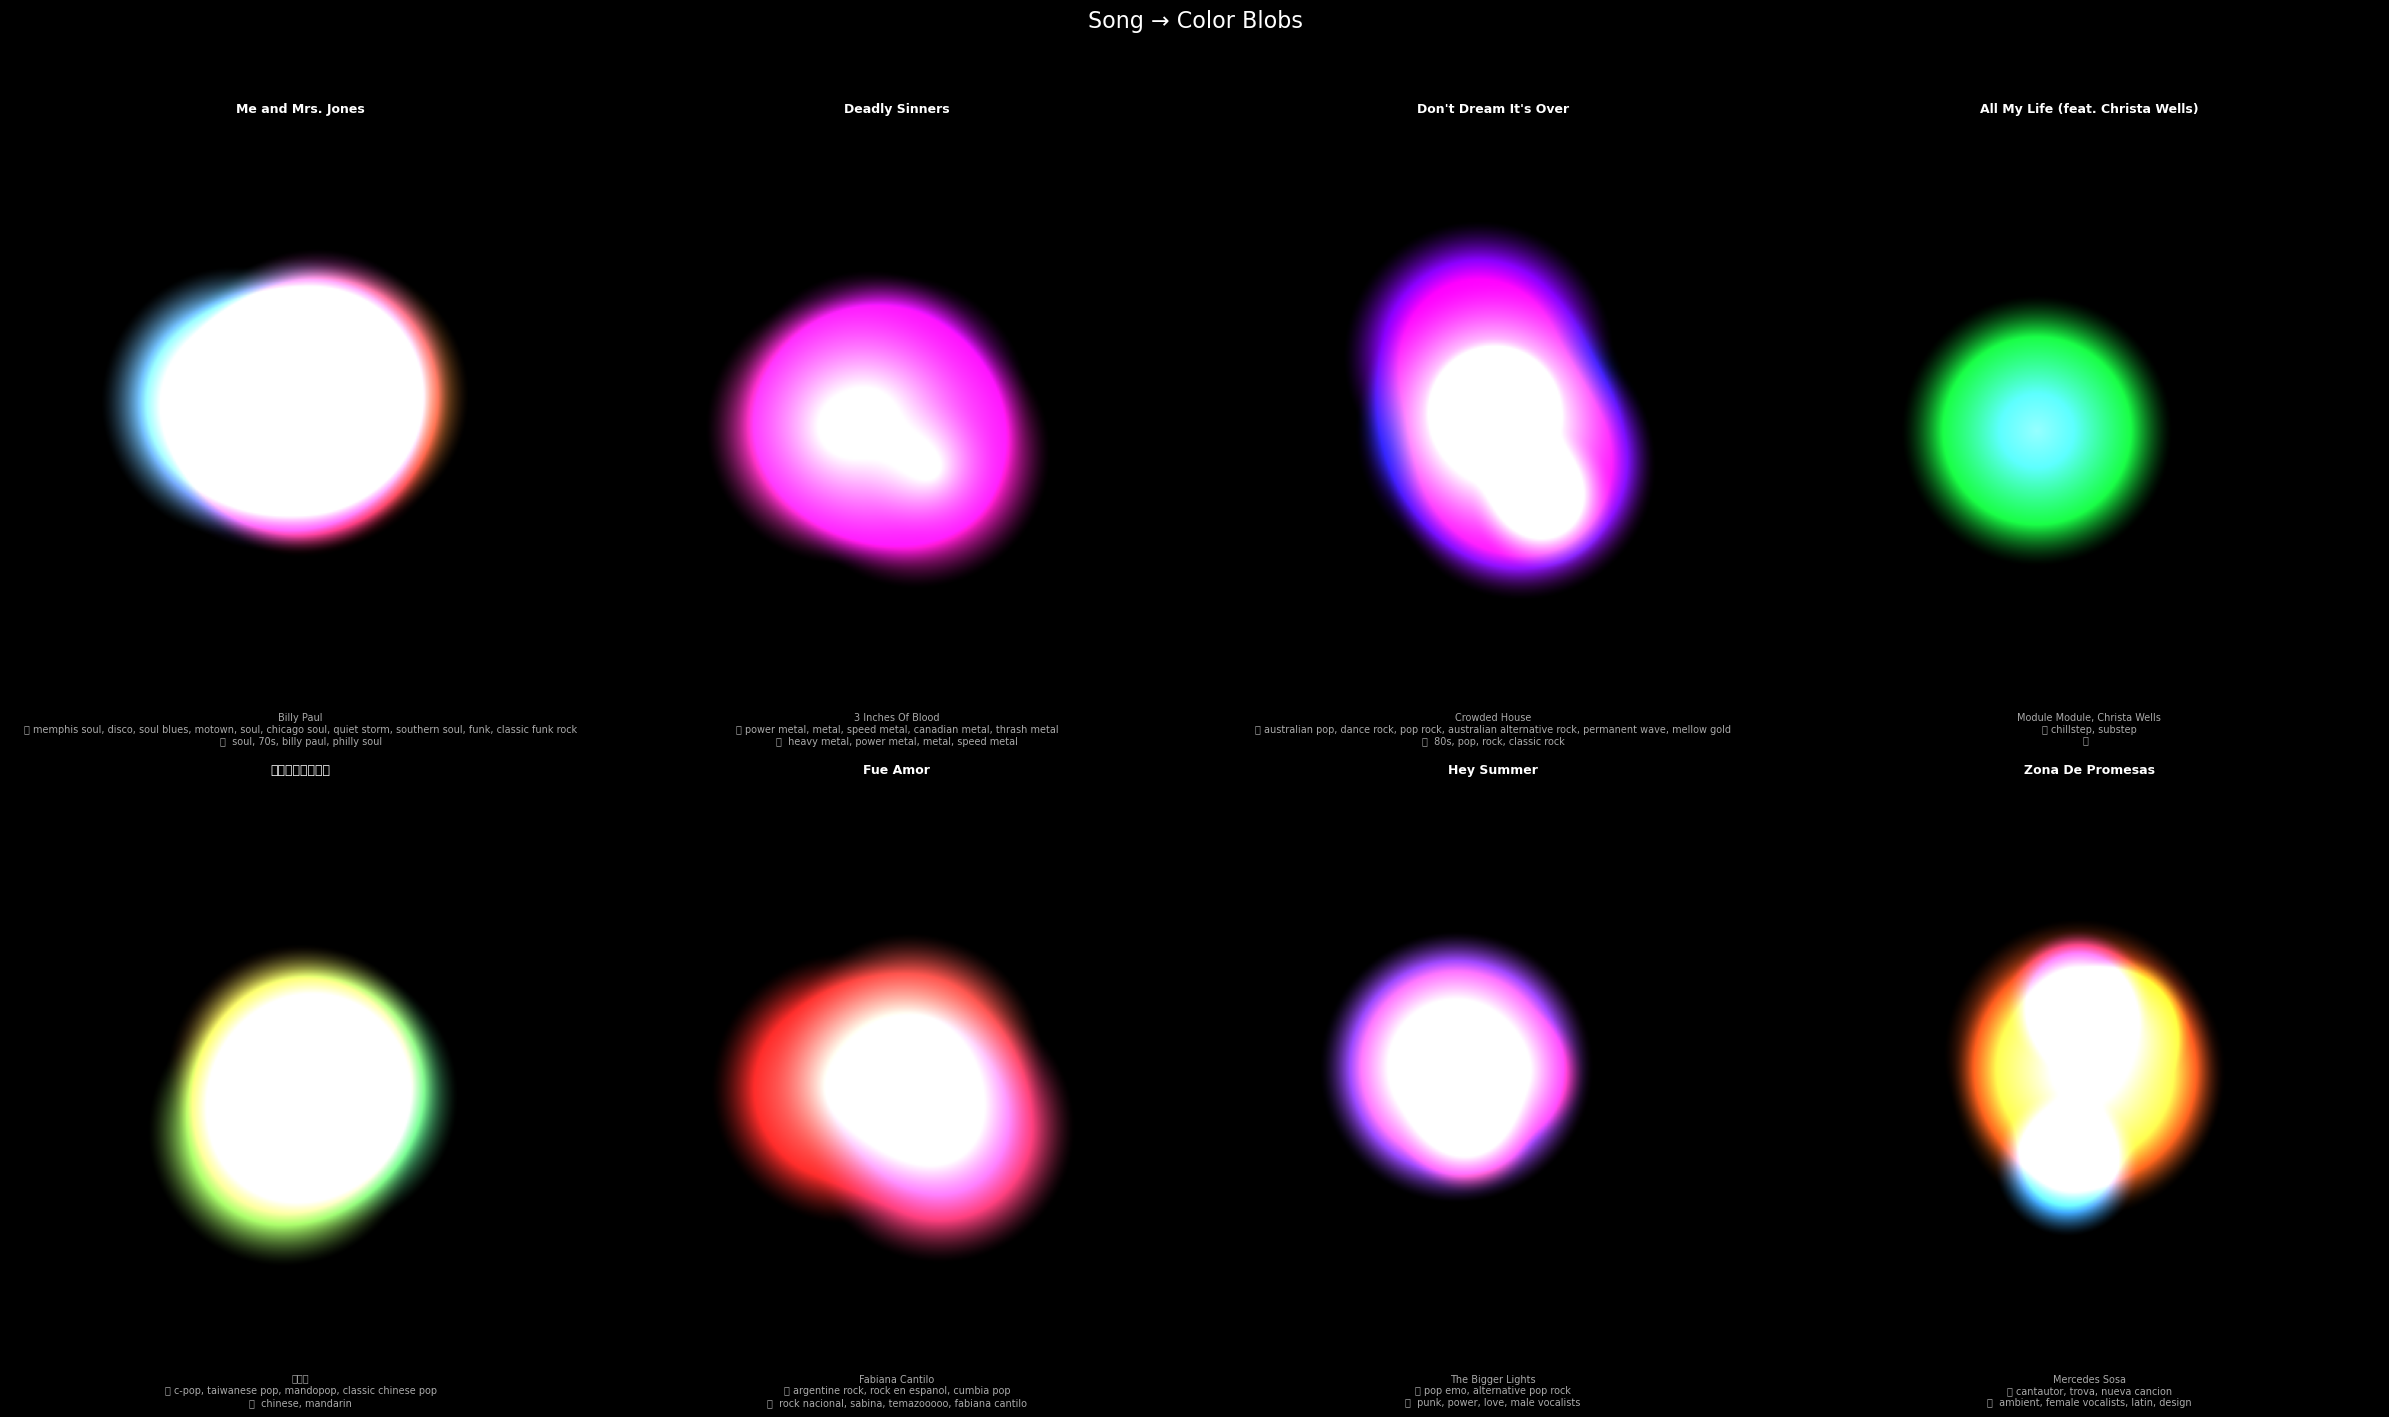

In [1012]:
# ── Plot ───────────────────────────────────────────────────────────────────────
TEST_IDS = [
    "5GYcaVfaFBHe2gzA6Oybgj",  # Me and Mrs. Jones   - soul blues
    "52mxPsGKbfyElOA0FCtc0l",  # Deadly Sinners       - thrash metal
    "68wIBE5dVVX8RyfZCJnAj5",  # Don't Dream It's Over - australian alt rock
    "4YP2nQliU8KsUB74XTP5aP",  # All My Life          - chillstep
    "1M97kKsHd1mw2rj4WCH2TA",  # 你怎麼捨得我難過      - c-pop
    "7c7e0Gr9AOzmJ8rDvOknI1",  # Fue Amor             - cumbia pop
    "4ygIRtbrrMlL8fBBADwzEj",  # Hey Summer           - pop emo
    "2EGq3O7pchSqjQ6gx82byi",  # Zona De Promesas     - cantautor
]

n_cols = 4
n_rows = math.ceil(len(TEST_IDS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 7 * n_rows))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, sid in enumerate(TEST_IDS):
    result = blob_from_spotify_id(sid, size=400)
    if result is None:
        continue

    img, song = result
    if img is None:
        continue

    row        = song_lookup.get(sid, {})
    genres_str = ", ".join(song["genres"])
    tags_str   = ", ".join(song["tags"][:4])

    axes[i].imshow(np.array(img))
    axes[i].set_facecolor('#000000')
    axes[i].set_title(row.get("name", sid), color='white', fontsize=9, fontweight='bold', pad=6)
    axes[i].set_xlabel(
        f"{row.get('artist','')}\n🎵 {genres_str}\n🏷  {tags_str}",
        color='#aaaaaa', fontsize=7, labelpad=8
    )
    axes[i].set_xticks([]); axes[i].set_yticks([])
    for spine in axes[i].spines.values():
        spine.set_visible(False)

for j in range(len(TEST_IDS), len(axes)):
    axes[j].axis('off')

plt.suptitle("Song → Color Blobs", fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/multi_blobs.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()